In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [7]:
base_credit = pd.read_csv("C:/Users/preaes/curso-machine-learning/bases_dados/credit_data.csv")

display(base_credit)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [8]:
base_credit.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [9]:
base_credit[base_credit['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [10]:
base_credit[base_credit['loan'] <= 1.377630]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


In [11]:
np.unique(base_credit['default'], return_counts='True')

(array([0, 1]), array([1717,  283]))

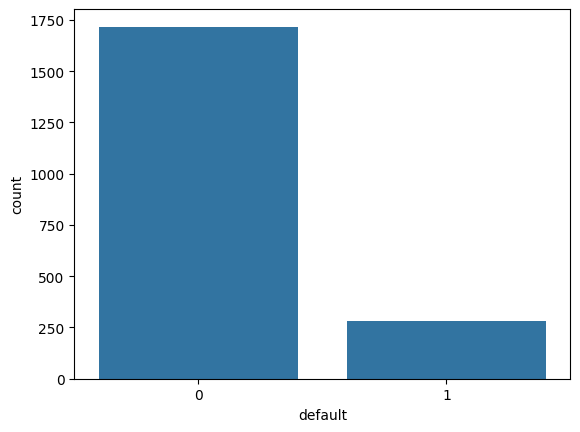

In [12]:
sns.countplot(x = base_credit['default']);

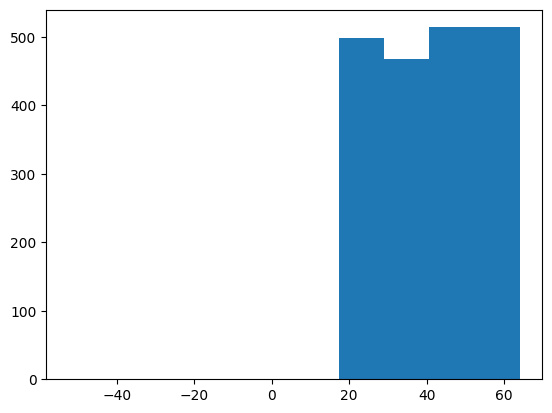

In [13]:
plt.hist(x = base_credit['age']);

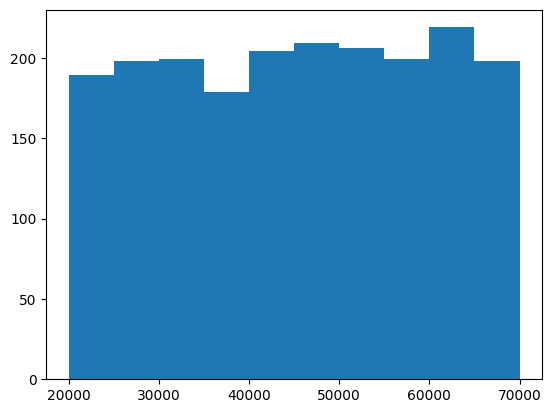

In [14]:
plt.hist(base_credit['income']);

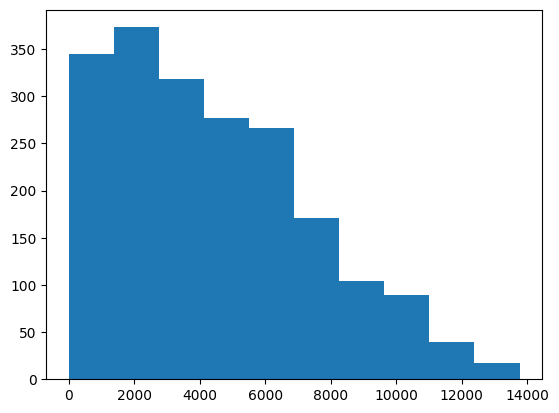

In [15]:
plt.hist(base_credit['loan']);

In [16]:
grafico = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'])
grafico.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [17]:
base_credit.loc[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [18]:
base_credit[base_credit['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


# Apagar a coluna inteira (de todos os registros de dados)

In [19]:
base_credit2 = base_credit.drop('age', axis=1)
base_credit2

,clientid,income,loan,default
0,1,66155.925095,8106.532131,0
1,2,34415.153966,6564.745018,0
2,3,57317.170063,8020.953296,0
3,4,42709.534201,6103.642260,0
4,5,66952.688845,8770.099235,1
...,...,...,...,...
1995,1996,59221.044874,1926.729397,0
1996,1997,69516.127573,3503.176156,0
1997,1998,44311.449262,5522.786693,1
1998,1999,43756.056605,1622.722598,0


# Apagar somento os registros com valores inconsistentes

In [20]:
base_credit.index # são os índices. Na linha abaixo, dizemos que queremos apagar os "índices" com idade negativa

RangeIndex(start=0, stop=2000, step=1)

In [21]:
base_credit3 = base_credit.drop(base_credit[base_credit['age'] < 0].index)
base_credit3

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [22]:
base_credit3.loc[base_credit3['age'] < 0]

,clientid,income,age,loan,default


# Preenches os valores inconsistentes manualmente

In [23]:
base_credit.mean()

clientid     1000.500000
income      45331.600018
age            40.807559
loan         4444.369695
default         0.141500
dtype: float64

In [24]:
base_credit['age'][base_credit['age'] > 0].mean()

np.float64(40.92770044906149)

In [25]:
base_credit.loc[base_credit['age'] < 0, 'age'] = 40.92
base_credit[base_credit['age'] < 0]
base_credit.head(27)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


# Tratamento de valores faltantes

In [26]:
base_credit.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [27]:
base_credit.loc[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [28]:
base_credit['age'].fillna(base_credit['age'].mean(), inplace=True) # usar o Inplace para substituir as mudanças na base de dados
base_credit.loc[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default


In [29]:
base_credit.loc[base_credit['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.927689,2082.625938,0
30,31,48528.852796,40.927689,6155.784670,0
31,32,23526.302555,40.927689,2862.010139,0


In [30]:
x_credit = base_credit.iloc[:, 1:4].values
y_credit = base_credit.iloc[:, 4].values

In [31]:
print(x_credit)
type(x_credit)

[[6.61559251e+04 5.90170151e+01 8.10653213e+03]
 [3.44151540e+04 4.81171531e+01 6.56474502e+03]
 [5.73171701e+04 6.31080495e+01 8.02095330e+03]
 ...
 [4.43114493e+04 2.80171669e+01 5.52278669e+03]
 [4.37560566e+04 6.39717958e+01 1.62272260e+03]
 [6.94365796e+04 5.61526170e+01 7.37883360e+03]]


numpy.ndarray

In [32]:
print(y_credit)
type(y_credit)

[0 0 0 ... 1 0 0]


numpy.ndarray

# Escalonamento: 
para deixar os valores na mesma escala para não afetar a precisão dos algoritmos preditivos
    Padronização x = (x - media(x)) / desvio padrao(x) ---- Mais indicado para quando temos outliers na base
    Normalização (x - minimo(x)) / maximo(x) - minimo(x)

In [33]:
print(x_credit[:, 0].min())
print(x_credit[:, 0].max())

20014.4894700497
69995.6855783239


In [34]:
print(x_credit[:, 1].min())
print(x_credit[:, 1].max())

18.055188510566897
63.971795841120205


In [35]:
print(x_credit[:, 2].min())
print(x_credit[:, 2].max())

1.37762959325451
13766.0512393337


In [36]:
from sklearn.preprocessing import StandardScaler

scaler_credit = StandardScaler()
x_credit = scaler_credit.fit_transform(x_credit)
x_credit

array([[ 1.45393393,  1.36538093,  1.20281942],
       [-0.76217555,  0.5426602 ,  0.69642695],
       [ 0.83682073,  1.67417189,  1.17471147],
       ...,
       [-0.07122592, -0.97448519,  0.35420081],
       [-0.11000289,  1.73936739, -0.92675625],
       [ 1.682986  ,  1.14917639,  0.96381038]], shape=(2000, 3))

In [37]:
x_credit[:, 0].min(), x_credit[:, 1].min(), x_credit[:, 2].min()

(np.float64(-1.7676158019964077),
 np.float64(-1.7264145408889917),
 np.float64(-1.4592791099462408))

In [38]:
x_credit[:, 0].max(), x_credit[:, 1].max(), x_credit[:, 2].max()

(np.float64(1.7220222385319197),
 np.float64(1.7393673928651967),
 np.float64(3.0616609141708273))

# Divisão entre bases de treinamento e teste

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
# random_state para fixar os mesmos registros nas bases de treinamento e teste
x_credit_treinamento, x_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(x_credit, y_credit, test_size=0.25, random_state=0)

In [41]:
x_credit_treinamento.shape

(1500, 3)

In [42]:
y_credit_treinamento.shape

(1500,)

In [43]:
x_credit_teste.shape, y_credit_teste.shape

((500, 3), (500,))

# Tunning

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [45]:
x_credit = np.concatenate((x_credit_treinamento, x_credit_teste), axis=0)
x_credit.shape

(2000, 3)

In [46]:
y_credit = np.concatenate((y_credit_treinamento, y_credit_teste), axis=0)
y_credit.shape

(2000,)

# Árvpre de Decisão

In [47]:
parametros = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [48]:
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
0.983


# Random Forest

In [49]:
parametros = {'criterion': ['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [50]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 40}
0.9865


# K Neighboors Classifier

In [51]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1, 2]}

In [52]:
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'n_neighbors': 20, 'p': 1}
0.9800000000000001


# Regressão Logística

In [53]:
parametros = {'tol': [0.0001, 0.00001, 0.000001],
              'C': [1.0, 1.5, 2.0],
              'solver': ['lbfgs', 'sag', 'saga']}


In [54]:
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.0, 'solver': 'lbfgs', 'tol': 0.0001}
0.9484999999999999


# SVM

In [55]:
parametros = {'tol': [0.001, 0.0001, 0.00001],
              'C': [1.0, 1.5, 2.0],
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}

In [56]:
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.5, 'kernel': 'rbf', 'tol': 0.001}
0.9829999999999999


# Redes Neurais Artificiais

In [57]:
parametros = {'activation': ['relu', 'logistic', 'tahn'],
              'solver': ['adam', 'sgd'],
              'batch_size': [10, 56]}

In [58]:
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros)
grid_search.fit(x_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users

{'activation': 'relu', 'batch_size': 56, 'solver': 'adam'}
0.9970000000000001


c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



# Aplicando o Tunning na Árvore de Decisão

In [59]:
from sklearn.model_selection import cross_val_score, KFold

In [60]:
resultados_arvore = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    
    arvore = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, splitter='best')
    scores = cross_val_score(arvore, x_credit, y_credit, cv=kfold)
    #print(scores)
    #print(scores.mean())
    resultados_arvore.append(scores.mean())

In [61]:
resultados_arvore

[np.float64(0.9869999999999999),
 np.float64(0.985),
 np.float64(0.9905000000000002),
 np.float64(0.9879999999999999),
 np.float64(0.9879999999999999),
 np.float64(0.9890000000000001),
 np.float64(0.9884999999999999),
 np.float64(0.9875),
 np.float64(0.9865),
 np.float64(0.9875),
 np.float64(0.9860000000000001),
 np.float64(0.9899999999999999),
 np.float64(0.9884999999999999),
 np.float64(0.9864999999999998),
 np.float64(0.985),
 np.float64(0.9859999999999998),
 np.float64(0.9855),
 np.float64(0.9904999999999999),
 np.float64(0.9875),
 np.float64(0.9869999999999999),
 np.float64(0.984),
 np.float64(0.9870000000000001),
 np.float64(0.9884999999999999),
 np.float64(0.9875),
 np.float64(0.9870000000000001),
 np.float64(0.9880000000000001),
 np.float64(0.9879999999999999),
 np.float64(0.9855),
 np.float64(0.9869999999999999),
 np.float64(0.9880000000000001)]

# Aplicando o Tunning no Random Forest

In [62]:
resultado_random_forest = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    random_forest = RandomForestClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, n_estimators=10)
    scores = cross_val_score(random_forest, x_credit, y_credit, cv=kfold)
    resultado_random_forest.append(scores.mean())

In [63]:
resultado_random_forest

[np.float64(0.9834999999999999),
 np.float64(0.9814999999999999),
 np.float64(0.9844999999999999),
 np.float64(0.983),
 np.float64(0.9855),
 np.float64(0.983),
 np.float64(0.9889999999999999),
 np.float64(0.9869999999999999),
 np.float64(0.9824999999999999),
 np.float64(0.986),
 np.float64(0.9825000000000002),
 np.float64(0.9844999999999999),
 np.float64(0.9845),
 np.float64(0.9819999999999999),
 np.float64(0.9834999999999999),
 np.float64(0.985),
 np.float64(0.9815000000000002),
 np.float64(0.9834999999999999),
 np.float64(0.984),
 np.float64(0.984),
 np.float64(0.9814999999999999),
 np.float64(0.9880000000000001),
 np.float64(0.9855),
 np.float64(0.983),
 np.float64(0.983),
 np.float64(0.9855),
 np.float64(0.9835),
 np.float64(0.9804999999999999),
 np.float64(0.9835),
 np.float64(0.9835)]

# Aplicando o Tuning no KNN

In [64]:
resultados_knn = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    knn = KNeighborsClassifier()
    scores = cross_val_score(knn, x_credit, y_credit, cv=kfold)
    resultados_knn.append(scores.mean())

# Aplicando o Tunning na Regressão Logística

In [70]:
resultados_logistica = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    logistica = LogisticRegression(C=1.0, solver='lbfgs', tol=0.0001)
    scores = cross_val_score(logistica, x_credit, y_credit, cv=kfold)
    resultados_logistica.append(scores.mean())

# Aplicando o Tunning no SVM

In [66]:
resultados_svm = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    svm = SVC(kernel='rbf', C=2.0)
    socres = cross_val_score(svm, x_credit, y_credit, cv=kfold)
    resultados_svm.append(scores.mean())

# Resultados RNA

In [67]:
resultados_rna = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    rede_neural = MLPClassifier(activation='relu', batch_size=56, solver='adam')
    scores = cross_val_score(rede_neural, x_credit, y_credit, cv=kfold)
    resultados_rna.append(scores.mean())

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\preaes\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users

# Análise dos Resultados

In [71]:
resultados = pd.DataFrame({'Arvore Decisão': resultados_arvore, 'Random Forest': resultado_random_forest,
                           'KNN': resultados_knn, 'Logística': resultados_logistica,
                           'SVM': resultados_svm, 'Rede Neural': resultados_rna})

In [72]:
resultados

,Arvore Decisão,Random Forest,KNN,Logística,SVM,Rede Neural
0,0.9870,0.9835,0.9815,0.9475,0.9465,0.9965
1,0.9850,0.9815,0.9800,0.9465,0.9465,0.9965
2,0.9905,0.9845,0.9795,0.9470,0.9465,0.9970
3,0.9880,0.9830,0.9780,0.9460,0.9465,0.9965
4,0.9880,0.9855,0.9820,0.9465,0.9465,0.9975
5,0.9890,0.9830,0.9780,0.9465,0.9465,0.9980
6,0.9885,0.9890,0.9805,0.9470,0.9465,0.9965
7,0.9875,0.9870,0.9800,0.9480,0.9465,0.9970
8,0.9865,0.9825,0.9795,0.9465,0.9465,0.9970
9,0.9875,0.9860,0.9820,0.9465,0.9465,0.9970


In [73]:
resultados.describe()

,Arvore Decisão,Random Forest,KNN,Logística,SVM,Rede Neural
count,30.00000,30.000000,30.000000,30.000000,3.000000e+01,30.000000
mean,0.98735,0.983933,0.980050,0.947000,9.465000e-01,0.997100
std,0.00156,0.001924,0.001533,0.000743,1.129203e-16,0.000481
min,0.98400,0.980500,0.977000,0.945500,9.465000e-01,0.996500
25%,0.98650,0.983000,0.979000,0.946500,9.465000e-01,0.996625
50%,0.98750,0.983500,0.980000,0.947000,9.465000e-01,0.997000
75%,0.98800,0.984875,0.981000,0.947500,9.465000e-01,0.997500
max,0.99050,0.989000,0.982500,0.948500,9.465000e-01,0.998000


In [75]:
((resultados.std())/resultados.mean())*100

Arvore Decisão    1.579994e-01
Random Forest     1.955555e-01
KNN               1.564463e-01
Logística         7.843520e-02
SVM               1.193030e-14
Rede Neural       4.820584e-02
dtype: float64